# Sonar + Vision Combined MOT Analysis

Synchronises sonar (~15.6 fps) and vision (~15–22 fps) ground truth using nanosecond timestamps 
(image filename = frame_id). All plots use **time in seconds from the earliest frame** of each sequence.

| | Sonar | Vision |
|---|---|---|
| Perspective | top-down (ROV below, looking up) | side-on |
| Classes | fish (1), net (2) | fish (1) |
| Coords | physical metres available | pixel only |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from pathlib import Path

try:
    from sklearn.cluster import DBSCAN
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("scikit-learn not found – clustering section will be skipped")

In [2]:
# ── Paths (relative to data-processing/) ─────────────────────────────────────
SONAR_ROOT  = Path("sonar/MOT")
VISION_ROOT = Path("vision/MOT")
SEQUENCES   = sorted([p.name for p in SONAR_ROOT.iterdir() if p.is_dir()])

GT_COLS = ["frame_id","track_id","x","y","w","h","not_ignored","class_id","visibility"]

# ── Sonar physical mapping (net_sonar_labelingview_config) ───────────────────
S_W, S_H   = 1200, 700
S_YMAX_M   = 8.0
S_XSPAN_M  = S_YMAX_M * np.sin(np.deg2rad(45.0))   # ≈ 5.657 m

def sonar_px_to_m(cx, cy):
    """Pixel centre → (x_m, y_m, range_m). ROV at bottom: row 699 = 0 m."""
    y_m = (S_H - 1 - cy) * (S_YMAX_M / (S_H - 1))
    x_m = cx * (2 * S_XSPAN_M / S_W) - S_XSPAN_M
    return x_m, y_m, np.sqrt(x_m**2 + y_m**2)

# ── Colour palette ────────────────────────────────────────────────────────────
C_SONAR  = "#1565C0"   # blue
C_VISION = "#2E7D32"   # green
C_NET    = "#C62828"   # red
C_BOTH   = "#6A1B9A"   # purple
C_NONE   = "#B0BEC5"   # grey
SEQ_COLS = ["#E65100","#1565C0","#2E7D32","#6A1B9A"]  # one per sequence

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

In [3]:
def _load(seq, root, modality):
    seq_path = root / seq
    img_dir  = seq_path / "frames" if modality == "sonar" else seq_path / "frames" / seq
    imgs     = sorted(img_dir.glob("*.jpg"))
    ts       = np.array([int(f.stem) for f in imgs], dtype=np.int64)

    df = pd.read_csv(seq_path / "gt" / "gt.txt", header=None, names=GT_COLS)
    df["frame_id"]     = df["frame_id"].astype(np.int64)
    df["sequence"]     = seq
    df["modality"]     = modality
    df["total_frames"] = len(ts)
    df["frame_norm"]   = df["frame_id"].map({t: i+1 for i, t in enumerate(ts)})

    if modality == "sonar":
        cx, cy = df["x"] + df["w"]/2, df["y"] + df["h"]/2
        df["cx"], df["cy"] = cx, cy
        df["x_m"], df["y_m"], df["range_m"] = sonar_px_to_m(cx, cy)
        df["w_m"] = df["w"] * (2 * S_XSPAN_M / S_W)
        df["y_near_m"] = np.maximum(0, (S_H - 1 - (df["y"] + df["h"])) * (S_YMAX_M / (S_H - 1)))
    return df, ts

def load_all():
    data = {}
    for seq in SEQUENCES:
        s_df, s_ts = _load(seq, SONAR_ROOT,  "sonar")
        v_df, v_ts = _load(seq, VISION_ROOT, "vision")

        t0 = min(s_ts[0], v_ts[0])   # nanosecond reference
        for df, ts in [(s_df, s_ts), (v_df, v_ts)]:
            df["time_s"] = (df["frame_id"] - t0) / 1e9

        # Full frame timelines (every frame, including empties)
        s_tl = pd.DataFrame({"frame_norm": range(1, len(s_ts)+1),
                              "time_s": (s_ts - t0) / 1e9})
        v_tl = pd.DataFrame({"frame_norm": range(1, len(v_ts)+1),
                              "time_s": (v_ts - t0) / 1e9})

        data[seq] = {
            "s": {"df": s_df, "ts": s_ts, "tl": s_tl},
            "v": {"df": v_df, "ts": v_ts, "tl": v_tl},
            "t0": t0,
            "dur": (max(s_ts[-1], v_ts[-1]) - t0) / 1e9,
        }
    return data

seqdata = load_all()


def frame_count(df, tl, class_id=1):
    """Fish/net count per frame (zero-filled using full timeline)."""
    fc = df[df["class_id"]==class_id].groupby("frame_norm").size().reset_index(name="n")
    out = tl.merge(fc, on="frame_norm", how="left")
    out["n"] = out["n"].fillna(0).astype(int)
    return out  # columns: frame_norm, time_s, n


def time_bin(series_time, series_val, bin_s=1.0, agg="mean"):
    """Bin a (time_s, value) series into fixed-width windows."""
    dur  = series_time.max()
    edges = np.arange(0, dur + bin_s, bin_s)
    cats  = pd.cut(series_time, bins=edges, labels=edges[:-1], include_lowest=True).astype(float)
    grp   = series_val.groupby(cats)
    fn    = grp.mean if agg == "mean" else grp.sum
    return fn().reset_index()

In [4]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for seq, d in seqdata.items():
    s, v = d["s"], d["v"]
    rows.append({
        "Sequence":           seq[-8:],
        "Duration (s)":       round(d["dur"], 1),
        "Sonar FPS":          round(len(s["ts"]) / d["dur"], 1),
        "Vision FPS":         round(len(v["ts"]) / d["dur"], 1),
        "Sonar fish annots":  int((s["df"]["class_id"]==1).sum()),
        "Vision fish annots": int((v["df"]["class_id"]==1).sum()),
        "Net annots":         int((s["df"]["class_id"]==2).sum()),
    })
display(pd.DataFrame(rows))

,Sequence,Duration (s),Sonar FPS,Vision FPS,Sonar fish annots,Vision fish annots,Net annots
0,14-31-29,67.8,15.6,22.1,946,4967,1060
1,17-02-00,55.0,15.6,22.0,442,1104,860
2,17-14-36,43.4,15.5,19.2,457,899,673
3,17-55-40,50.1,15.6,15.9,780,1667,781


## 1  Synchronised detection timeline
Sonar (blue) and vision (green) fish counts on a common time axis.  
Red shading = net detected by sonar.

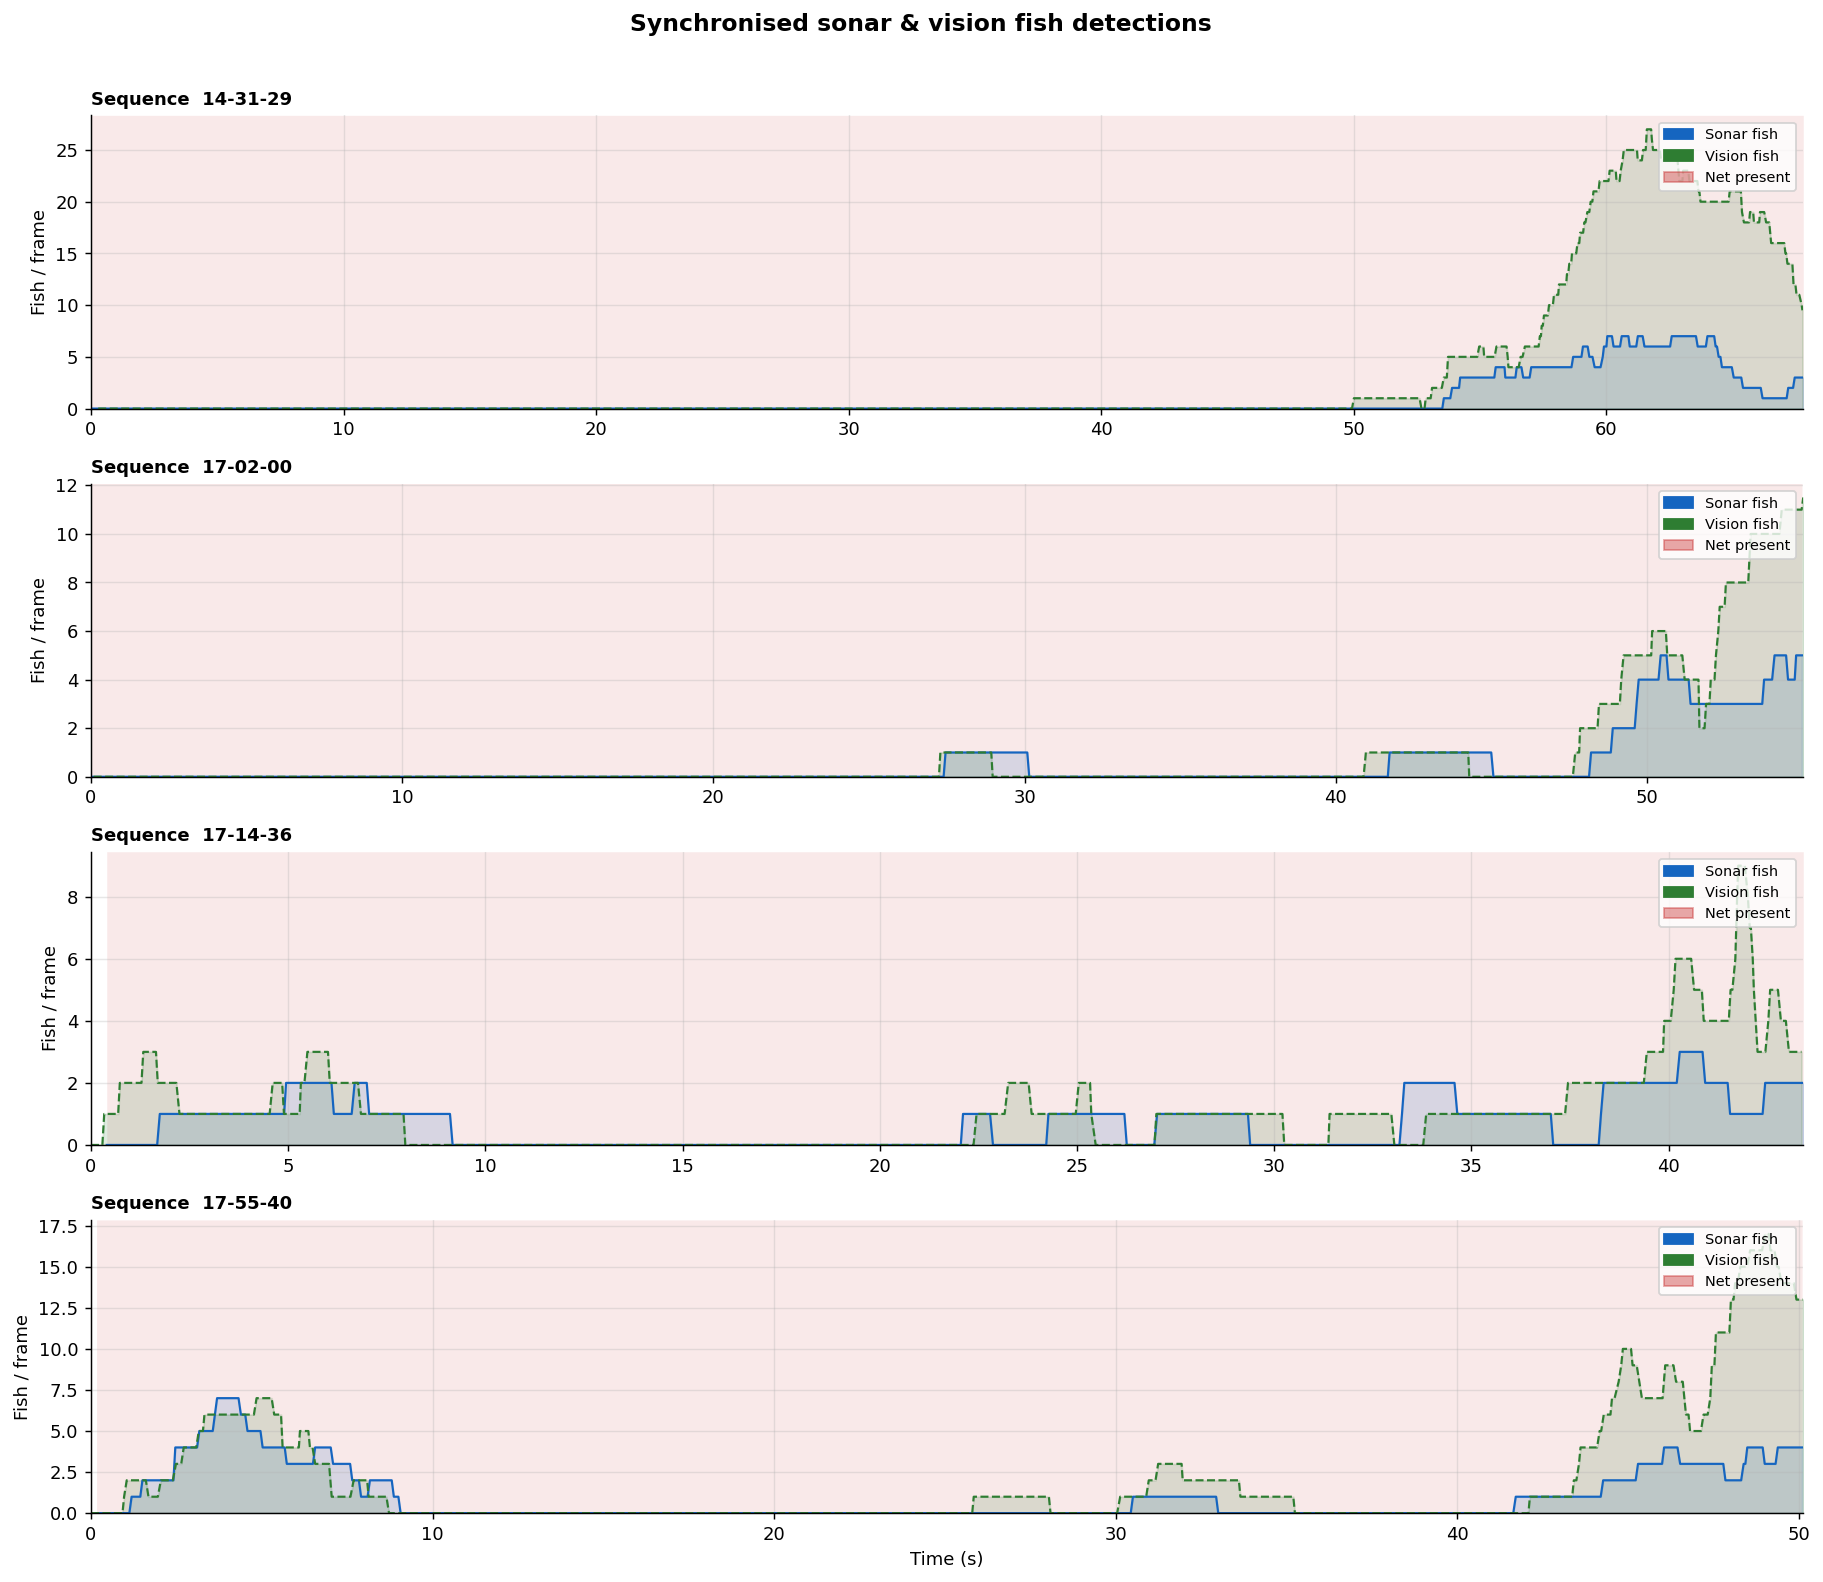

In [5]:
SMOOTH = 7   # rolling-median window for display

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 3 * len(SEQUENCES)), sharex=False)

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_fc   = frame_count(d["s"]["df"], d["s"]["tl"], class_id=1)
    v_fc   = frame_count(d["v"]["df"], d["v"]["tl"], class_id=1)
    net_fc = frame_count(d["s"]["df"], d["s"]["tl"], class_id=2)

    s_smooth = s_fc["n"].rolling(SMOOTH, center=True, min_periods=1).median()
    v_smooth = v_fc["n"].rolling(SMOOTH, center=True, min_periods=1).median()

    # Net presence background shading
    ax.fill_between(net_fc["time_s"], 0, 1, where=net_fc["n"] > 0,
                    transform=ax.get_xaxis_transform(),
                    color=C_NET, alpha=0.10, linewidth=0)

    ax.fill_between(s_fc["time_s"],  s_smooth, alpha=0.15, color=C_SONAR)
    ax.fill_between(v_fc["time_s"],  v_smooth, alpha=0.15, color=C_VISION)
    ax.plot(s_fc["time_s"],  s_smooth, lw=1.2, color=C_SONAR,  label="sonar fish")
    ax.plot(v_fc["time_s"],  v_smooth, lw=1.2, color=C_VISION, label="vision fish", ls="--")

    ax.set_ylabel("Fish / frame")
    ax.set_ylim(bottom=0)
    ax.set_xlim(0, d["dur"])
    ax.set_title(f"Sequence  {seq[-8:]}", fontsize=10, fontweight="bold", loc="left")

    handles = [Patch(color=C_SONAR,  label="Sonar fish"),
               Patch(color=C_VISION, label="Vision fish"),
               Patch(color=C_NET, alpha=0.4, label="Net present")]
    ax.legend(handles=handles, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Synchronised sonar & vision fish detections", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sync_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 2  Detection modality agreement
Each second is classified: both detect fish / sonar only / vision only / neither.

/tmp/ipykernel_212601/2521456200.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  agree = pd.concat([s_present, v_present], axis=1).fillna(False)


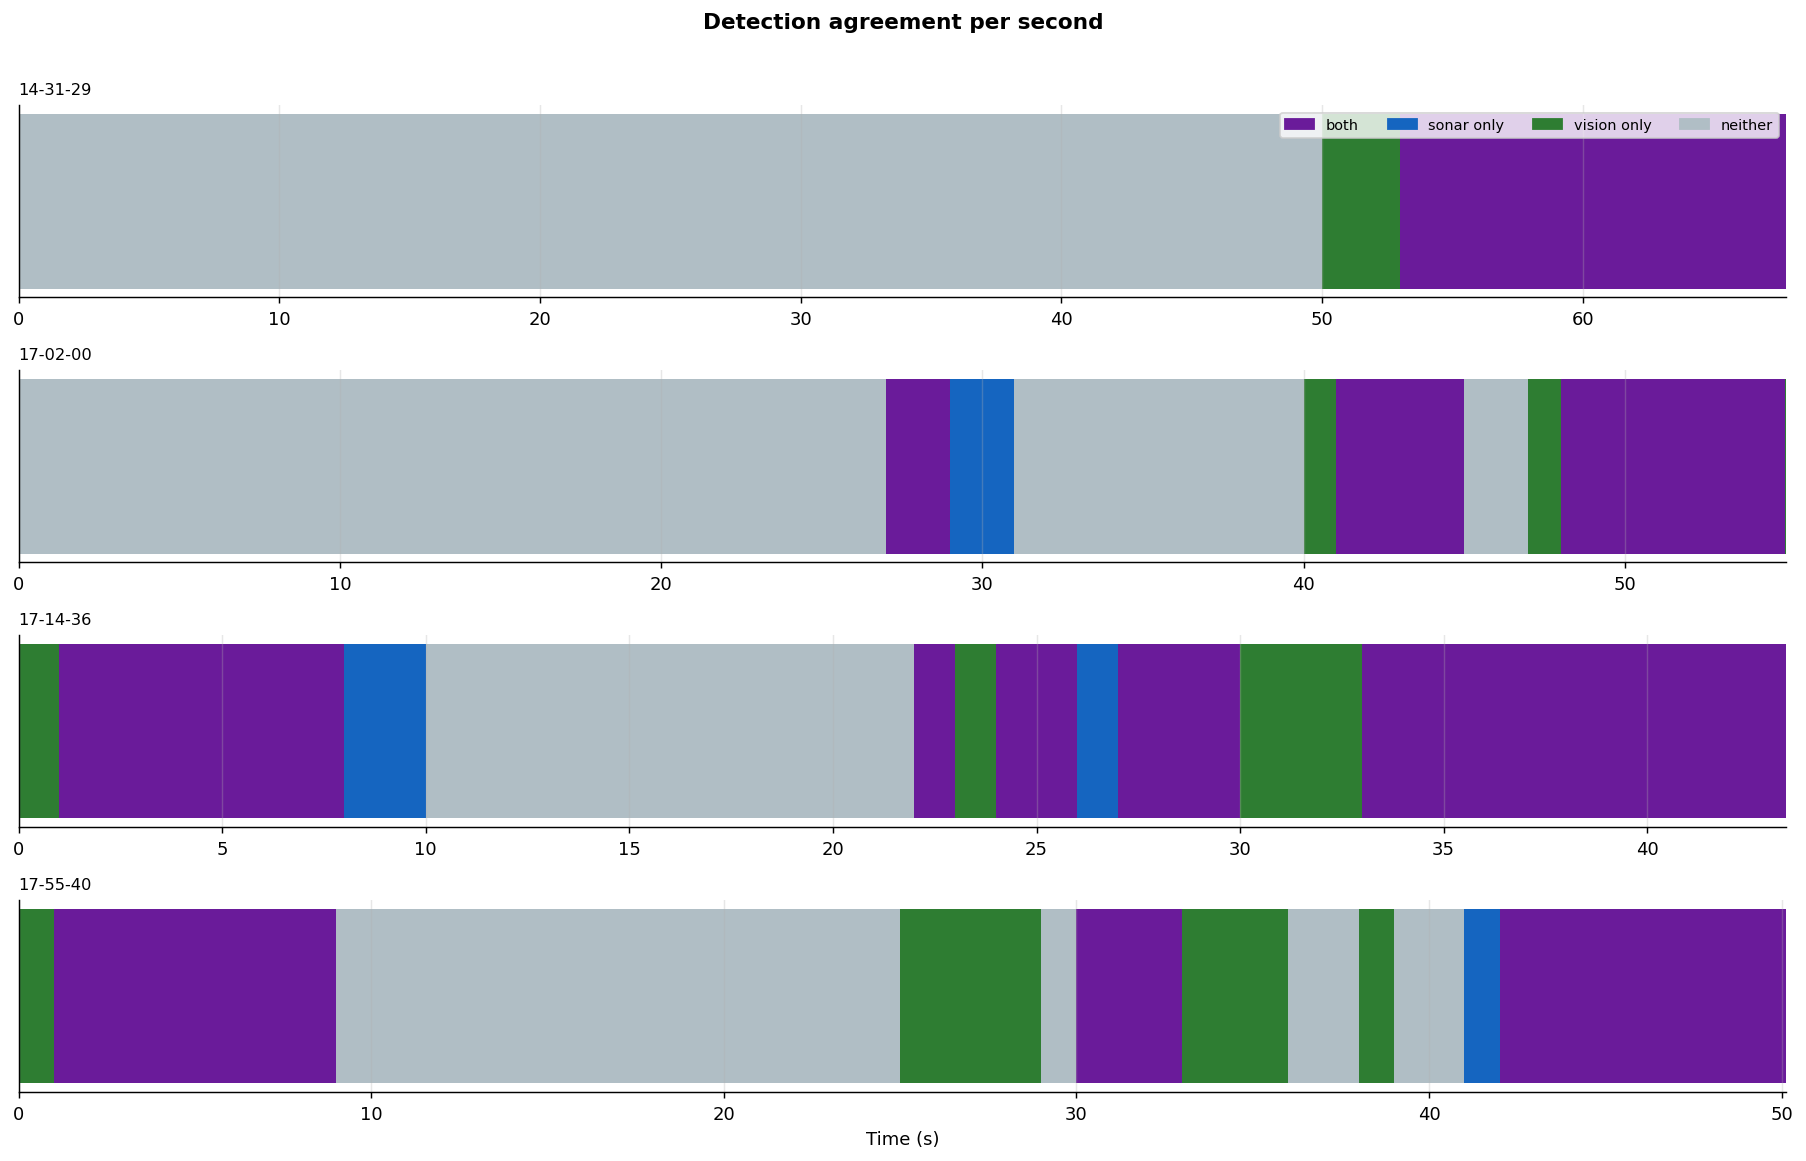

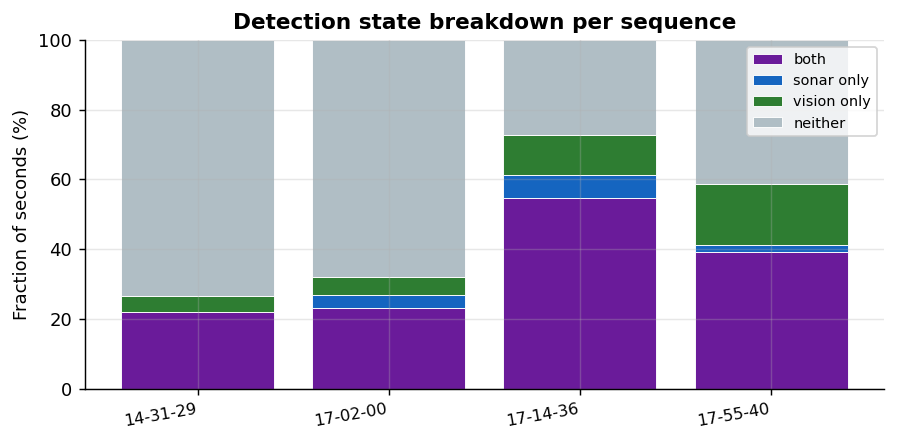

In [6]:
BIN_S = 1.0
STATES = {"both": C_BOTH, "sonar only": C_SONAR, "vision only": C_VISION, "neither": C_NONE}

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 2.2 * len(SEQUENCES)))

all_fracs = []

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_fc = frame_count(d["s"]["df"], d["s"]["tl"])
    v_fc = frame_count(d["v"]["df"], d["v"]["tl"])

    edges = np.arange(0, d["dur"] + BIN_S, BIN_S)
    s_bin = pd.cut(s_fc["time_s"], edges, labels=edges[:-1], include_lowest=True).astype(float)
    v_bin = pd.cut(v_fc["time_s"], edges, labels=edges[:-1], include_lowest=True).astype(float)

    s_present = s_fc.groupby(s_bin)["n"].max().rename("s") > 0
    v_present = v_fc.groupby(v_bin)["n"].max().rename("v") > 0
    agree = pd.concat([s_present, v_present], axis=1).fillna(False)

    state = np.where( agree["s"] &  agree["v"], 0,
            np.where( agree["s"] & ~agree["v"], 1,
            np.where(~agree["s"] &  agree["v"], 2, 3)))

    cmap_list = [C_BOTH, C_SONAR, C_VISION, C_NONE]
    colors = [cmap_list[s] for s in state]
    bins_t = agree.index.values

    for t, c in zip(bins_t, colors):
        ax.barh(0, BIN_S, left=t, height=0.8, color=c, linewidth=0)

    ax.set_yticks([])
    ax.set_xlim(0, d["dur"])
    ax.set_title(seq[-8:], fontsize=9, loc="left")

    # Fraction bar chart inset
    fracs = [np.mean(state == i) for i in range(4)]
    all_fracs.append(fracs)

axes[-1].set_xlabel("Time (s)")
legend_handles = [Patch(color=c, label=l) for l, c in STATES.items()]
axes[0].legend(handles=legend_handles, loc="upper right", fontsize=8, ncol=4)
fig.suptitle("Detection agreement per second", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("detection_agreement_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Fraction summary bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(SEQUENCES))
labels = list(STATES.keys())
colors = list(STATES.values())
bottom = np.zeros(len(SEQUENCES))
for i, (lbl, col) in enumerate(STATES.items()):
    vals = [all_fracs[j][i] * 100 for j in range(len(SEQUENCES))]
    ax.bar(x, vals, bottom=bottom, color=col, label=lbl, edgecolor="white", linewidth=0.5)
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in SEQUENCES], rotation=10, ha="right", fontsize=9)
ax.set_ylabel("Fraction of seconds (%)")
ax.set_title("Detection state breakdown per sequence", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("detection_agreement_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## 3  Sonar vs vision fish count correlation
1-second bins. Each point is one second of footage; colour = sequence.

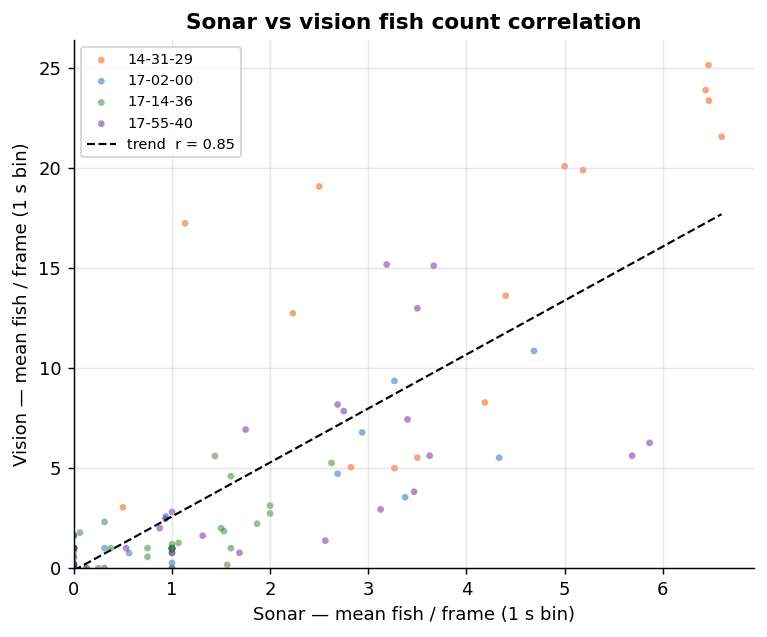

Overall Pearson r = 0.852


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

all_s, all_v = [], []

for i, (seq, d) in enumerate(seqdata.items()):
    s_fc = frame_count(d["s"]["df"], d["s"]["tl"])
    v_fc = frame_count(d["v"]["df"], d["v"]["tl"])

    s_b = time_bin(s_fc["time_s"], s_fc["n"], bin_s=1.0)
    v_b = time_bin(v_fc["time_s"], v_fc["n"], bin_s=1.0)
    s_b.columns = ["bin", "s"]
    v_b.columns = ["bin", "v"]
    merged = s_b.merge(v_b, on="bin")

    ax.scatter(merged["s"], merged["v"], s=14, alpha=0.5, color=SEQ_COLS[i],
               label=seq[-8:], edgecolors="none")
    all_s.extend(merged["s"].tolist())
    all_v.extend(merged["v"].tolist())

all_s, all_v = np.array(all_s), np.array(all_v)
r = np.corrcoef(all_s, all_v)[0, 1]

# Trend line
m, b = np.polyfit(all_s, all_v, 1)
xs = np.linspace(0, all_s.max(), 100)
ax.plot(xs, m*xs + b, color="black", lw=1.2, ls="--", label=f"trend  r = {r:.2f}")

ax.set_xlabel("Sonar — mean fish / frame (1 s bin)")
ax.set_ylabel("Vision — mean fish / frame (1 s bin)")
ax.set_title("Sonar vs vision fish count correlation", fontweight="bold")
ax.legend(fontsize=8)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig("correlation_sonar_vision.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Overall Pearson r = {r:.3f}")

## 4  Fish clustering over time (sonar, DBSCAN)
DBSCAN on physical (x_m, y_m) sonar coordinates each frame.  
`eps = 0.4 m`, `min_samples = 2`.  
**Shoaling fraction** = fraction of fish in a cluster with ≥ 2 members.

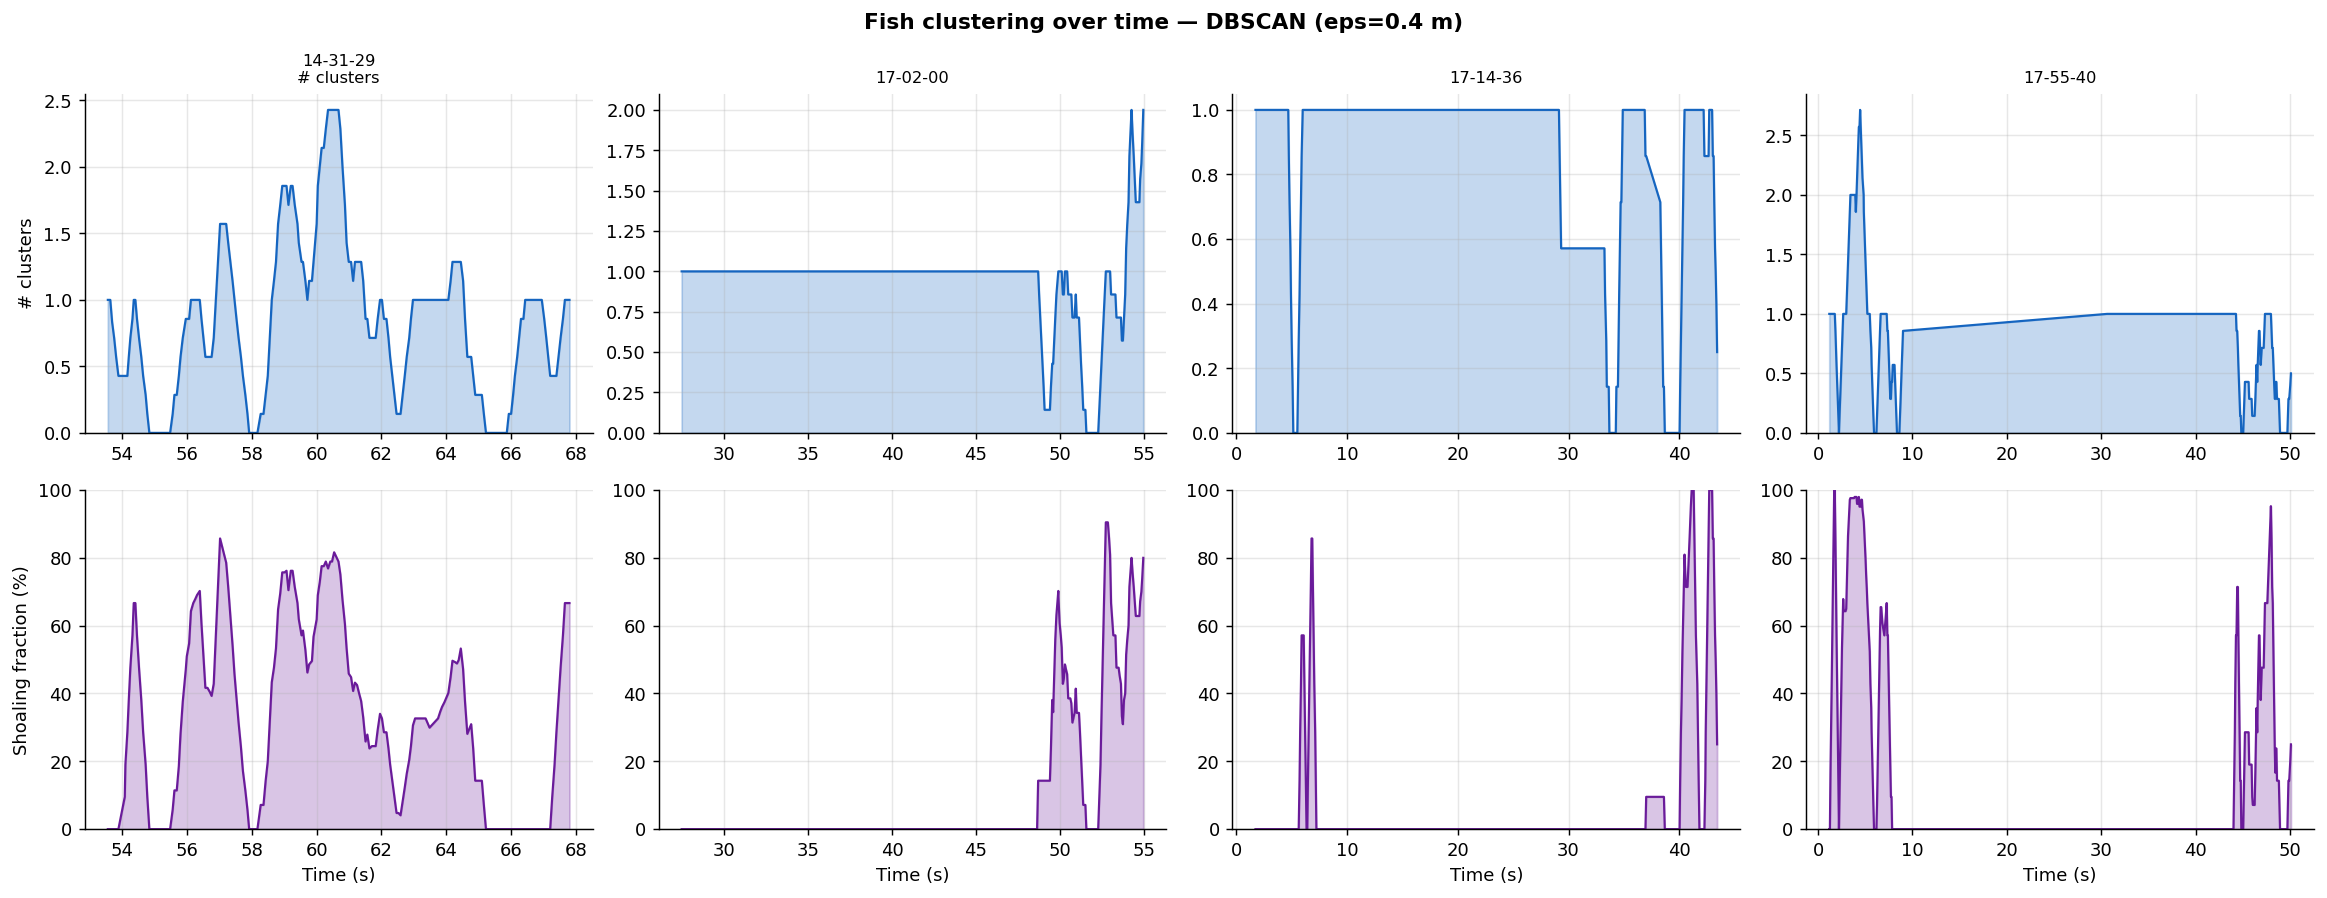

In [8]:
if not HAS_SKLEARN:
    print("Skipping — scikit-learn not available")
else:
    EPS_M, MIN_S = 0.4, 2

    def cluster_per_frame(s_df):
        rows = []
        for (seq, fn), grp in s_df[s_df["class_id"]==1].groupby(["sequence","frame_norm"]):
            pts = grp[["x_m","y_m"]].values
            n   = len(pts)
            if n < 2:
                rows.append({"sequence":seq,"frame_norm":fn,"n_fish":n,
                             "n_clusters":min(n,1),"shoaling_frac":0.0,"largest":n})
                continue
            lbl  = DBSCAN(eps=EPS_M, min_samples=MIN_S).fit_predict(pts)
            good = lbl[lbl >= 0]
            nc   = len(set(good))
            lg   = int(np.bincount(good).max()) if len(good) else 0
            rows.append({"sequence":seq,"frame_norm":fn,"n_fish":n,
                         "n_clusters":nc,"shoaling_frac":len(good)/n,"largest":lg})
        return pd.DataFrame(rows)

    fig, axes = plt.subplots(2, len(SEQUENCES), figsize=(4.5*len(SEQUENCES), 7))

    for col, (seq, d) in enumerate(seqdata.items()):
        s_df = d["s"]["df"]
        s_tl = d["s"]["tl"]
        cl   = cluster_per_frame(s_df)
        cl   = cl.merge(s_tl[["frame_norm","time_s"]], on="frame_norm", how="left")

        sm_nc = cl["n_clusters"].rolling(7,   center=True, min_periods=1).mean()
        sm_sf = cl["shoaling_frac"].rolling(7, center=True, min_periods=1).mean()

        # Top: n_clusters over time
        ax = axes[0, col]
        ax.fill_between(cl["time_s"], sm_nc, alpha=0.25, color=C_SONAR)
        ax.plot(cl["time_s"], sm_nc, lw=1.2, color=C_SONAR)
        ax.set_title(seq[-8:], fontsize=9)
        ax.set_ylim(bottom=0)
        if col == 0: ax.set_ylabel("# clusters")

        # Bottom: shoaling fraction over time
        ax2 = axes[1, col]
        ax2.fill_between(cl["time_s"], sm_sf*100, alpha=0.25, color=C_BOTH)
        ax2.plot(cl["time_s"], sm_sf*100, lw=1.2, color=C_BOTH)
        ax2.set_ylim(0, 100); ax2.set_xlabel("Time (s)")
        if col == 0: ax2.set_ylabel("Shoaling fraction (%)")

    axes[0,0].set_title(f"{SEQUENCES[0][-8:]}\n# clusters", fontsize=9)
    fig.suptitle(f"Fish clustering over time — DBSCAN (eps={EPS_M} m)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fish_clustering_time.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5  Spatial fish density — top-down physical space (sonar)
All sequences combined. Net median position per sequence shown as a dashed line.

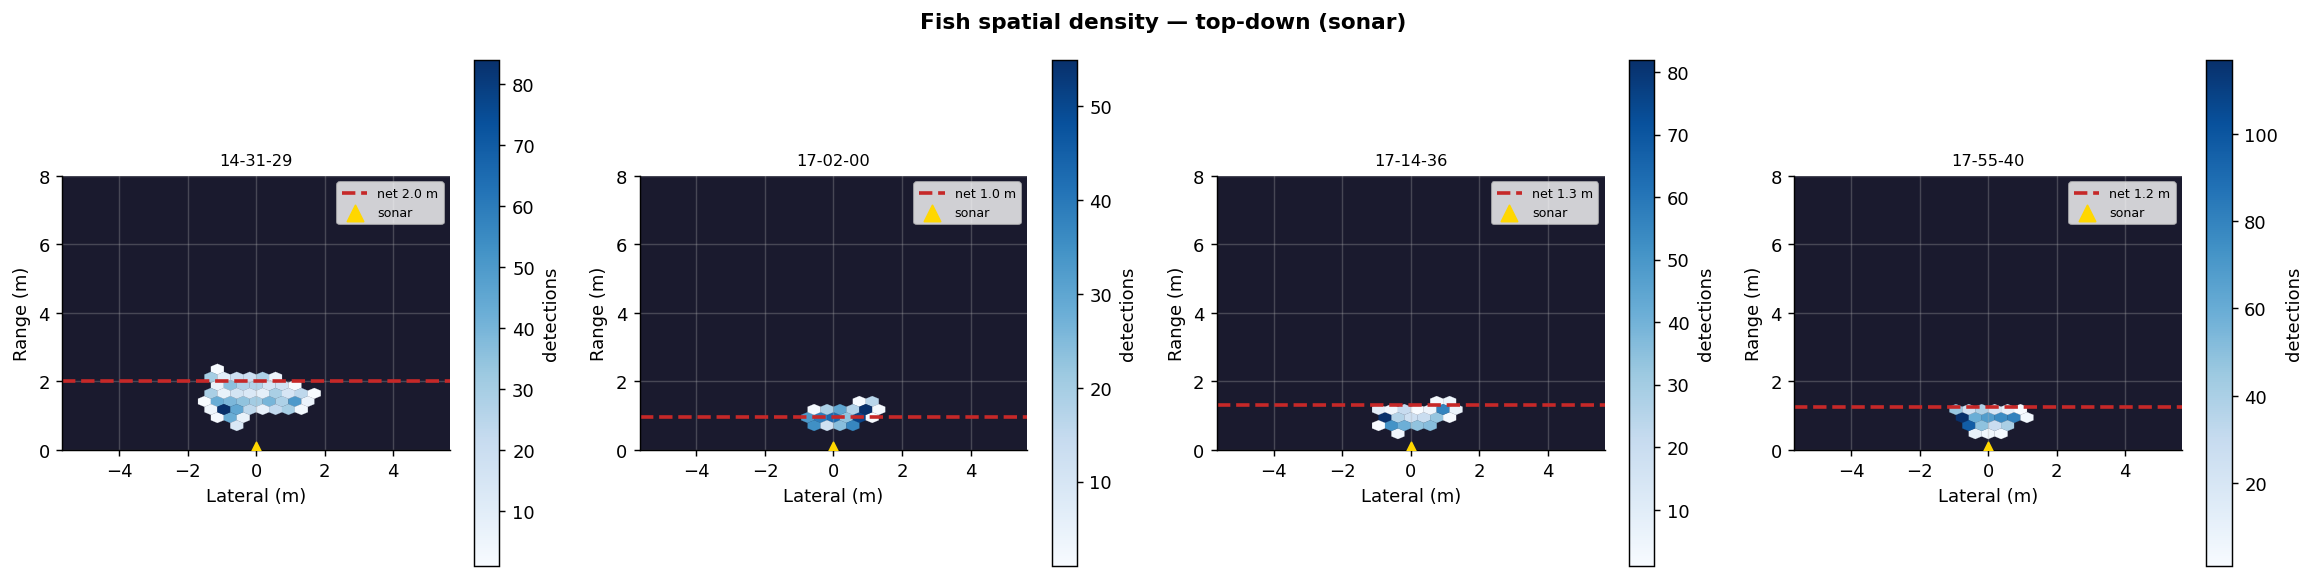

In [9]:
fig, axes = plt.subplots(1, len(SEQUENCES), figsize=(4.5*len(SEQUENCES), 4.5))

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_df = d["s"]["df"]
    fish = s_df[s_df["class_id"]==1]
    net  = s_df[s_df["class_id"]==2]

    hb = ax.hexbin(fish["x_m"], fish["y_m"],
                   gridsize=30, cmap="Blues",
                   extent=[-S_XSPAN_M, S_XSPAN_M, 0, S_YMAX_M],
                   mincnt=1, linewidths=0.1)
    plt.colorbar(hb, ax=ax, label="detections")

    if not net.empty:
        net_y = net["y_m"].median()
        ax.axhline(net_y, color=C_NET, lw=2, ls="--", label=f"net {net_y:.1f} m")

    # ROV marker at origin (bottom)
    ax.scatter(0, 0, s=80, marker="^", color="gold", zorder=5, label="sonar")

    ax.set_xlim(-S_XSPAN_M, S_XSPAN_M)
    ax.set_ylim(0, S_YMAX_M)
    ax.set_xlabel("Lateral (m)")
    ax.set_ylabel("Range (m)")
    ax.set_title(seq[-8:], fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=7)
    ax.set_facecolor("#1a1a2e")

fig.suptitle("Fish spatial density — top-down (sonar)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fish_spatial_density_topdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Fish proximity to net over time (sonar)
Per frame: fraction of fish within 0.5 m / 1.0 m / 2.0 m of the net bbox centre.

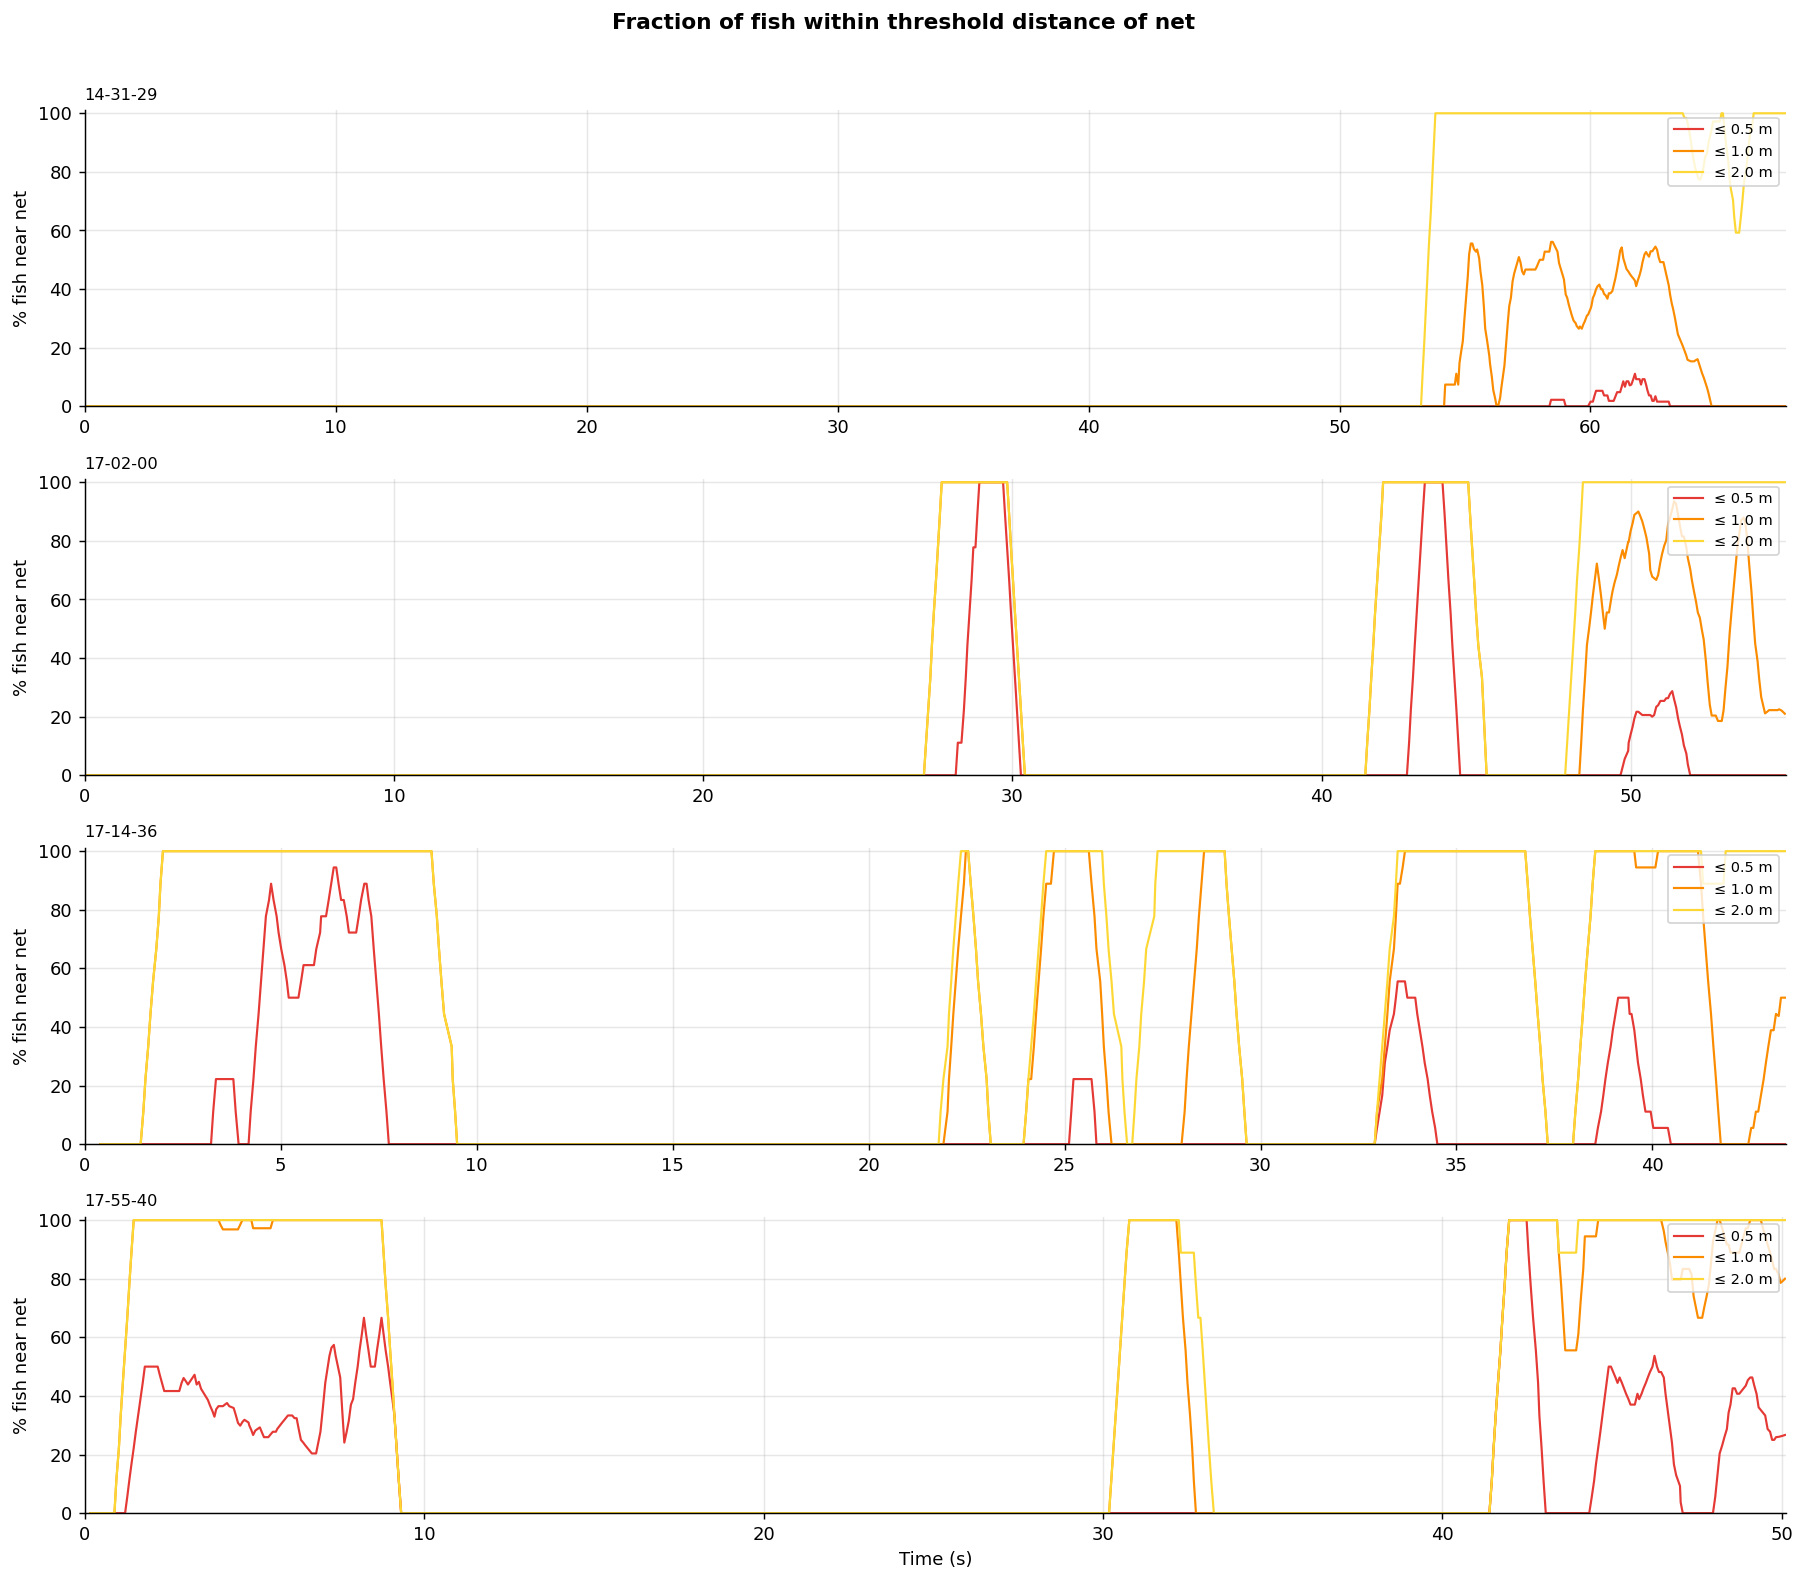

In [10]:
THRESHOLDS = [0.5, 1.0, 2.0]
THR_COLS   = ["#E53935", "#FB8C00", "#FDD835"]  # red / orange / yellow

fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 3*len(SEQUENCES)))

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_df = d["s"]["df"]
    s_tl = d["s"]["tl"]
    fish = s_df[s_df["class_id"]==1]
    net  = s_df[s_df["class_id"]==2]

    if net.empty or fish.empty:
        ax.set_title(f"{seq[-8:]} — insufficient data", fontsize=9)
        continue

    # Net centre per frame
    net_pos = net.groupby("frame_norm")[["x_m","y_m"]].mean().rename(
              columns={"x_m":"nx","y_m":"ny"})
    mf = fish.join(net_pos, on="frame_norm").dropna(subset=["nx"])
    mf["d2net"] = np.sqrt((mf["x_m"]-mf["nx"])**2 + (mf["y_m"]-mf["ny"])**2)

    for thr, col in zip(THRESHOLDS, THR_COLS):
        near  = (mf["d2net"] <= thr).groupby(mf["frame_norm"]).mean().reset_index()
        near.columns = ["frame_norm","frac"]
        tl2   = s_tl.merge(near, on="frame_norm", how="left")
        tl2["frac"] = tl2["frac"].fillna(0)
        sm = tl2["frac"].rolling(9, center=True, min_periods=1).mean()
        ax.plot(tl2["time_s"], sm*100, lw=1.2, color=col, label=f"≤ {thr} m")

    ax.set_ylabel("% fish near net")
    ax.set_ylim(0, 101)
    ax.set_xlim(0, d["dur"])
    ax.set_title(seq[-8:], fontsize=9, loc="left")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Fraction of fish within threshold distance of net",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fish_proximity_to_net.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Net distance & fish count — dual-axis
Net range from sonar (left axis) and sonar + vision fish counts (right axis) on the same time axis.

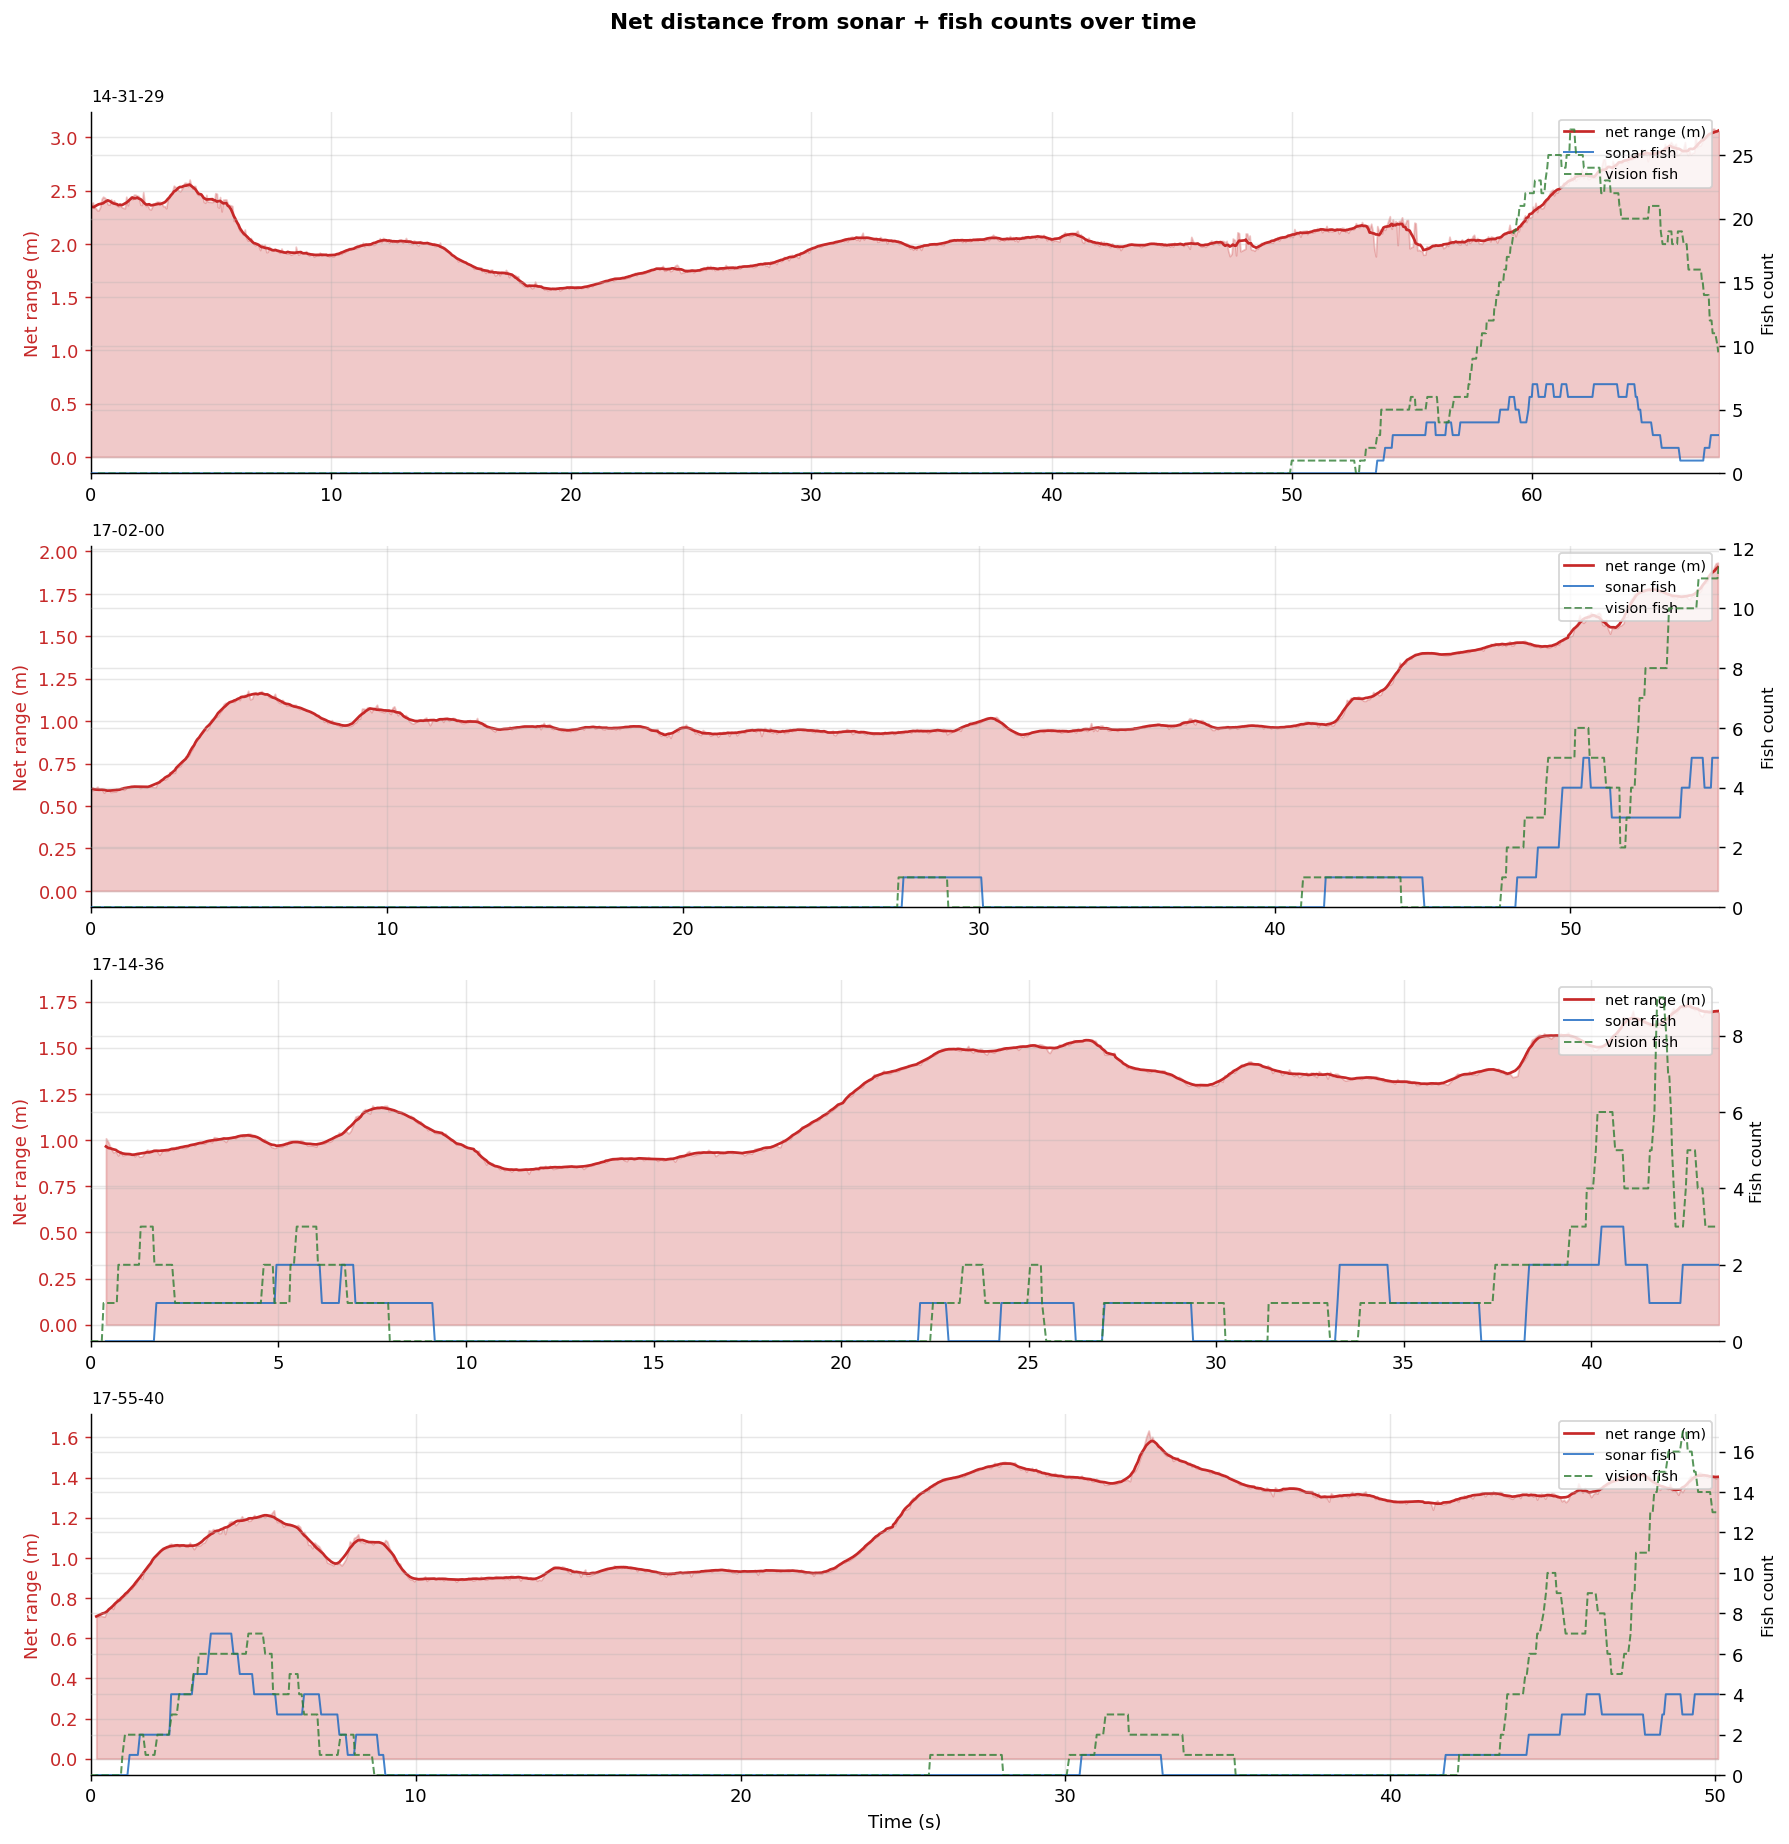

In [11]:
fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(14, 3.5*len(SEQUENCES)))

for ax, (seq, d) in zip(axes, seqdata.items()):
    s_df = d["s"]["df"]
    s_tl = d["s"]["tl"]
    v_fc = frame_count(d["v"]["df"], d["v"]["tl"])
    net  = s_df[s_df["class_id"]==2]

    # Net range (median per frame, merged to full sonar timeline)
    if not net.empty:
        nr = net.groupby("frame_norm")["range_m"].median().reset_index()
        net_tl = s_tl.merge(nr, on="frame_norm", how="left")
        ax.fill_between(net_tl["time_s"], net_tl["range_m"],
                        alpha=0.25, color=C_NET, label="_")
        ax.plot(net_tl["time_s"],
                net_tl["range_m"].rolling(9, center=True, min_periods=1).mean(),
                color=C_NET, lw=1.5, label="net range (m)")
        ax.set_ylabel("Net range (m)", color=C_NET)
        ax.tick_params(axis="y", colors=C_NET)

    # Fish counts on twin axis
    ax2 = ax.twinx()
    s_fc = frame_count(s_df, s_tl)
    ax2.plot(s_fc["time_s"],
             s_fc["n"].rolling(7, center=True, min_periods=1).median(),
             color=C_SONAR, lw=1.1, alpha=0.8, label="sonar fish")
    ax2.plot(v_fc["time_s"],
             v_fc["n"].rolling(7, center=True, min_periods=1).median(),
             color=C_VISION, lw=1.1, alpha=0.8, ls="--", label="vision fish")
    ax2.set_ylabel("Fish count", fontsize=9)
    ax2.set_ylim(bottom=0)
    ax2.spines[["top","bottom","left"]].set_visible(False)

    ax.set_xlim(0, d["dur"])
    ax.set_title(seq[-8:], fontsize=9, loc="left")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, fontsize=8, loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Net distance from sonar + fish counts over time",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("net_range_fish_count.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  Fish cluster snapshots in physical space
Four time snapshots per sequence showing DBSCAN cluster assignments in (x_m, y_m) space.  
Each colour = one cluster; grey = unclustered fish; dashed = net position.

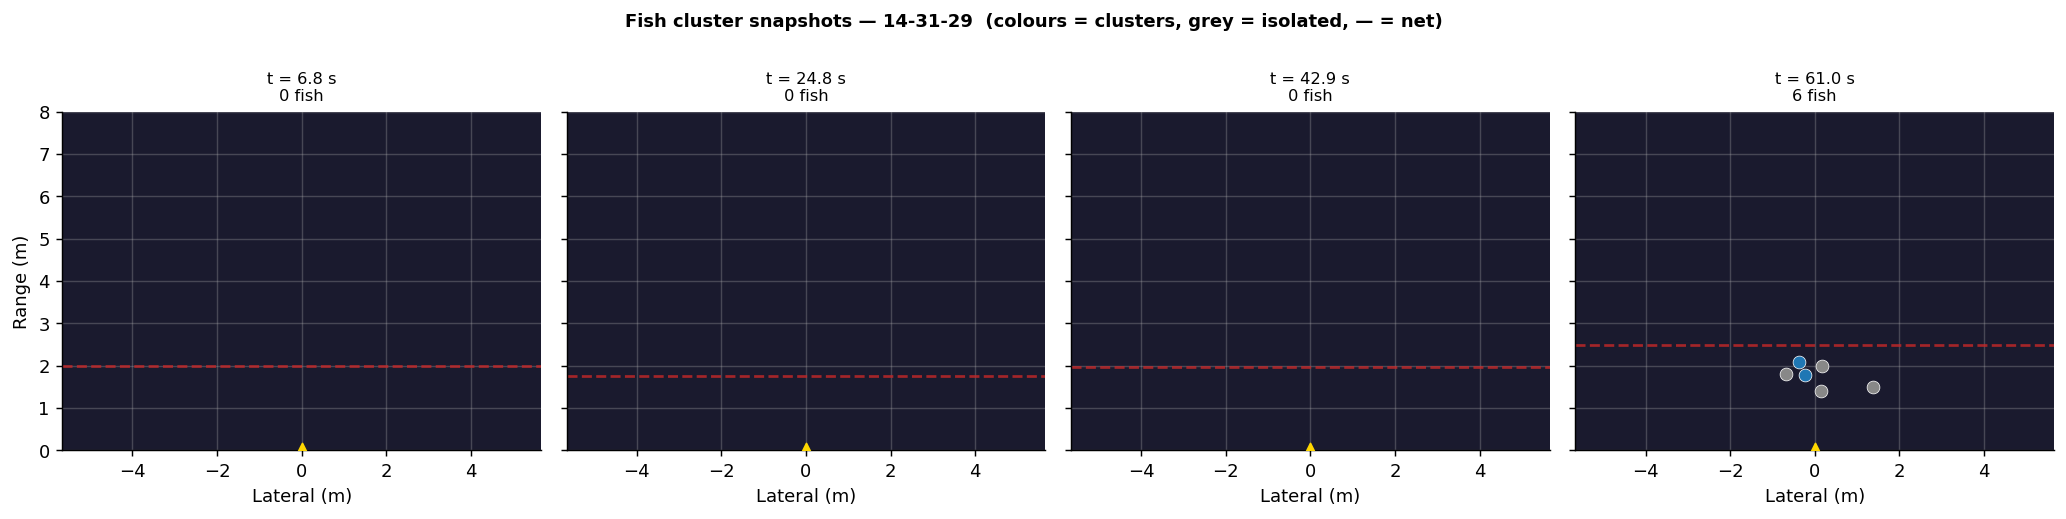

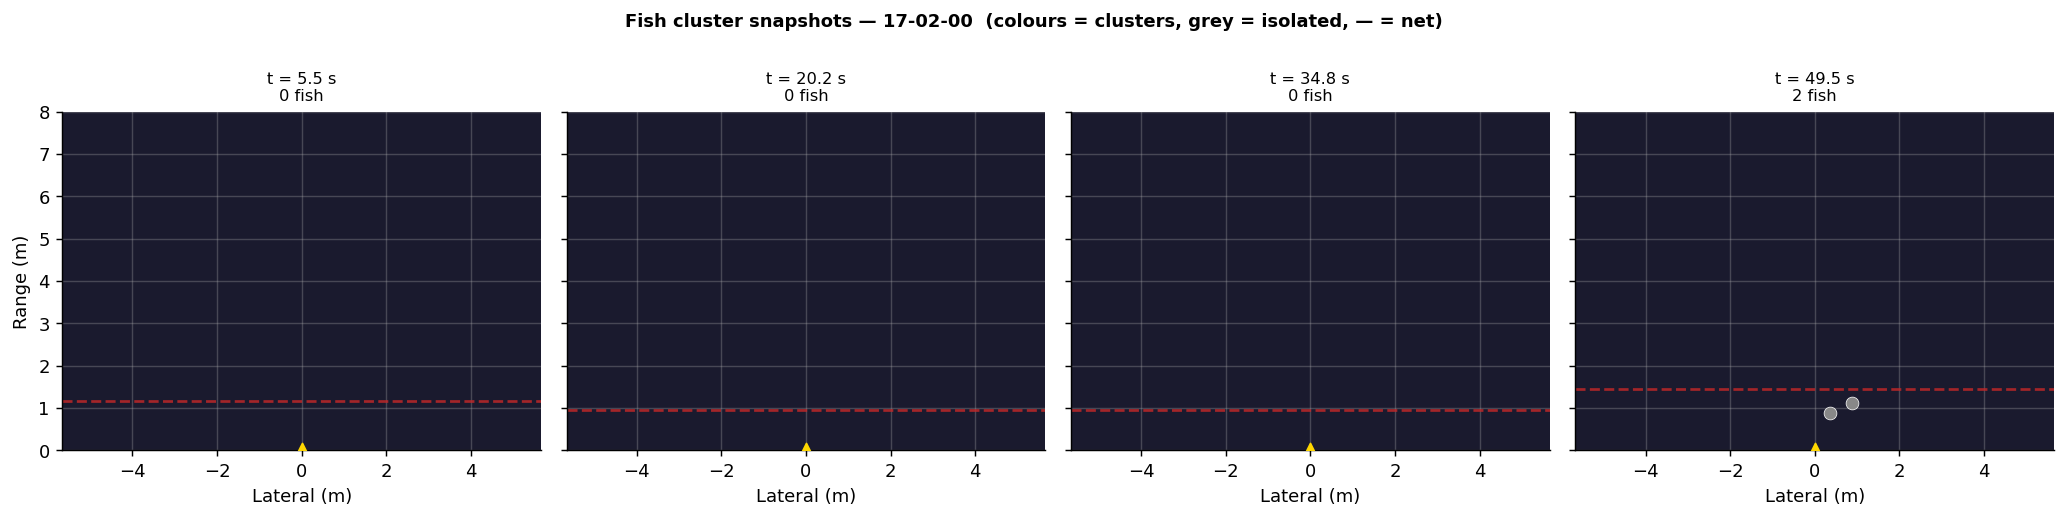

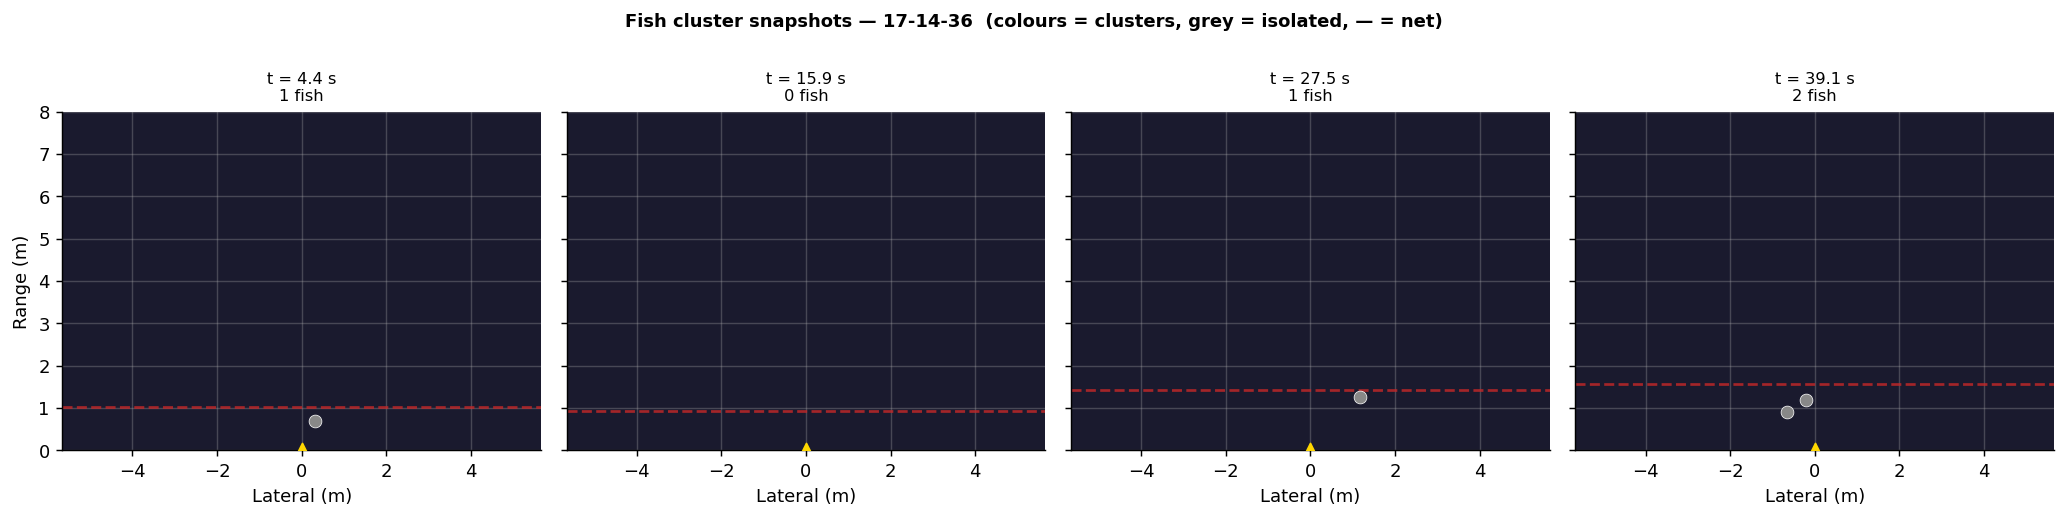

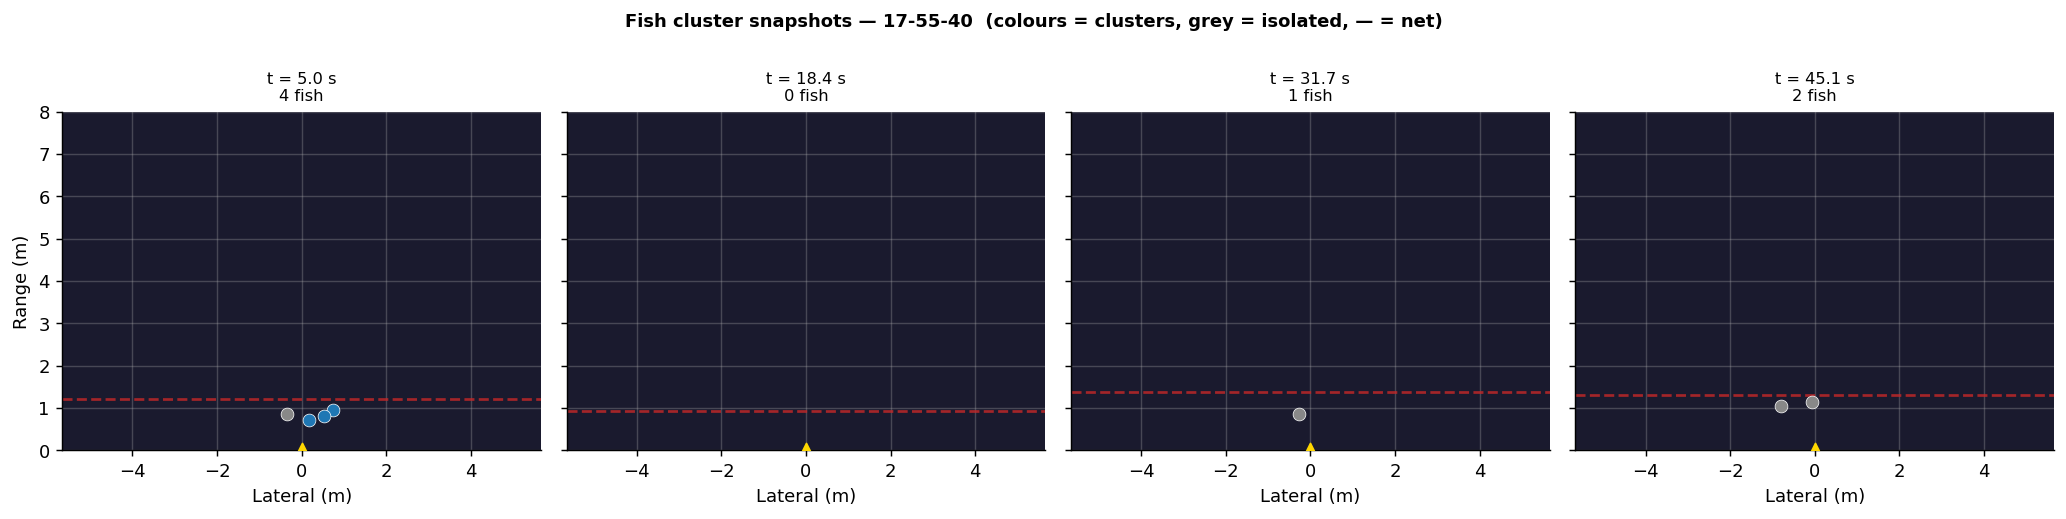

In [12]:
if not HAS_SKLEARN:
    print("Skipping — scikit-learn not available")
else:
    N_SNAPS = 4
    SNAP_CMAP = plt.get_cmap("tab10")

    for seq, d in seqdata.items():
        s_df = d["s"]["df"]
        s_tl = d["s"]["tl"]
        fish = s_df[s_df["class_id"]==1]
        net  = s_df[s_df["class_id"]==2]

        # Pick N_SNAPS time points spread across the sequence
        snap_times = np.linspace(0.1 * d["dur"], 0.9 * d["dur"], N_SNAPS)

        fig, axes = plt.subplots(1, N_SNAPS, figsize=(4*N_SNAPS, 4), sharey=True)

        for ax, t_target in zip(axes, snap_times):
            # Nearest sonar frame to t_target
            nearest = (s_tl["time_s"] - t_target).abs().idxmin()
            fn = s_tl.loc[nearest, "frame_norm"]
            t_actual = s_tl.loc[nearest, "time_s"]

            pts = fish[fish["frame_norm"]==fn][["x_m","y_m"]].values
            net_y = net[net["frame_norm"]==fn]["y_m"].median() if not net[net["frame_norm"]==fn].empty else np.nan

            if len(pts) >= 2:
                labels = DBSCAN(eps=EPS_M, min_samples=MIN_S).fit_predict(pts)
            elif len(pts) == 1:
                labels = np.array([-1])
            else:
                labels = np.array([])

            for lbl in set(labels):
                mask  = labels == lbl
                color = "#888888" if lbl == -1 else SNAP_CMAP(lbl % 10)
                ax.scatter(pts[mask, 0], pts[mask, 1], s=50, color=color,
                           edgecolors="white", linewidths=0.4, zorder=3)

            if not np.isnan(net_y):
                ax.axhline(net_y, color=C_NET, lw=1.5, ls="--", alpha=0.8)

            ax.scatter(0, 0, s=60, marker="^", color="gold", zorder=5)
            ax.set_xlim(-S_XSPAN_M, S_XSPAN_M)
            ax.set_ylim(0, S_YMAX_M)
            ax.set_xlabel("Lateral (m)")
            ax.set_title(f"t = {t_actual:.1f} s\n{len(pts)} fish", fontsize=9)
            ax.set_facecolor("#1a1a2e")
            ax.set_aspect("equal")

        axes[0].set_ylabel("Range (m)")
        fig.suptitle(f"Fish cluster snapshots — {seq[-8:]}  "
                     f"(colours = clusters, grey = isolated, — = net)",
                     fontsize=10, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"cluster_snapshots_{seq[-8:]}.png", dpi=150, bbox_inches="tight")
        plt.show()

## 9  Track statistics: sonar vs vision
Track length (number of annotated frames) distributions for both modalities.

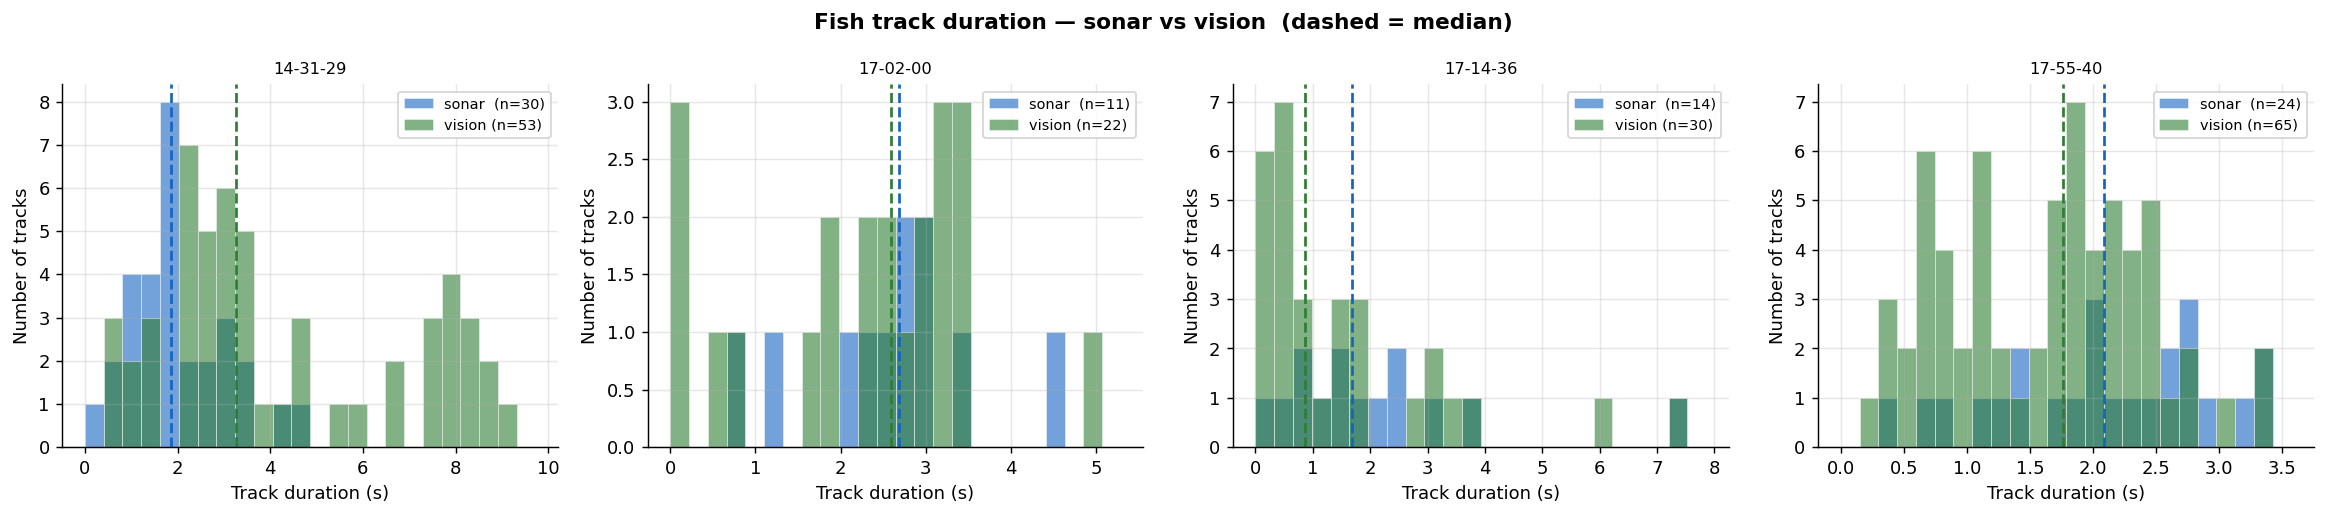

In [13]:
fig, axes = plt.subplots(1, len(SEQUENCES), figsize=(4.5*len(SEQUENCES), 4), sharey=False)

for ax, (seq, d) in zip(axes, seqdata.items()):
    fps_s = len(d["s"]["ts"]) / d["dur"]
    fps_v = len(d["v"]["ts"]) / d["dur"]

    s_len = (d["s"]["df"][d["s"]["df"]["class_id"]==1]
             .groupby("track_id")["frame_norm"].nunique() / fps_s)  # convert to seconds
    v_len = (d["v"]["df"][d["v"]["df"]["class_id"]==1]
             .groupby("track_id")["frame_norm"].nunique() / fps_v)

    bins = np.linspace(0, max(s_len.max(), v_len.max()) * 1.05, 25)
    ax.hist(s_len, bins=bins, alpha=0.6, color=C_SONAR,  label=f"sonar  (n={len(s_len)})",
            edgecolor="white", linewidth=0.4)
    ax.hist(v_len, bins=bins, alpha=0.6, color=C_VISION, label=f"vision (n={len(v_len)})",
            edgecolor="white", linewidth=0.4)

    for vals, col in [(s_len, C_SONAR), (v_len, C_VISION)]:
        ax.axvline(vals.median(), color=col, lw=1.5, ls="--")

    ax.set_xlabel("Track duration (s)")
    ax.set_ylabel("Number of tracks")
    ax.set_title(seq[-8:], fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Fish track duration — sonar vs vision  (dashed = median)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("track_durations.png", dpi=150, bbox_inches="tight")
plt.show()